In [1]:
%matplotlib inline

In [ ]:
# LABORATÓRIO 02 — EXPERIMENTANDO O ACO

import numpy as np
import random
import matplotlib.pyplot as plt

CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5


def obter_vizinhos(no):
    vizinhos = []
    for proximo in range(len(CUSTOS)):
        if proximo != no and CUSTOS[no][proximo] != np.inf:
            vizinhos.append(proximo)
    return vizinhos


def calcular_custo(rota):
    total = 0
    for i in range(len(rota) - 1):
        origem = rota[i]
        destino = rota[i + 1]
        total += CUSTOS[origem][destino]
    return total


def rodar_aco(num_formigas, num_iteracoes, alpha, beta, taxa_evaporacao, q=100, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    feromonio = np.ones_like(CUSTOS, dtype=float)
    feromonio[CUSTOS == np.inf] = 0

    def escolher_proximo(no_atual, visitados):
        vizinhos = obter_vizinhos(no_atual)
        candidatos = [no for no in vizinhos if no not in visitados]
        if not candidatos:
            return None

        atratividades = []
        for proximo in candidatos:
            fer = feromonio[no_atual][proximo]
            custo = CUSTOS[no_atual][proximo]
            atratividade = (fer ** alpha) * (1 / custo) ** beta
            atratividades.append(atratividade)

        soma = sum(atratividades)
        probabilidades = [valor / soma for valor in atratividades]
        return random.choices(candidatos, weights=probabilidades, k=1)[0]

    def construir_rota():
        rota = [ORIGEM]
        atual = ORIGEM
        while atual != DESTINO:
            proximo = escolher_proximo(atual, rota)
            if proximo is None:
                return None
            rota.append(proximo)
            atual = proximo
        return rota

    def depositar_feromonio(rota, custo):
        deposito = q / custo
        for i in range(len(rota) - 1):
            origem = rota[i]
            destino = rota[i + 1]
            feromonio[origem][destino] += deposito

    def evaporar_feromonio():
        nonlocal feromonio
        feromonio = feromonio * (1 - taxa_evaporacao)
        feromonio[CUSTOS == np.inf] = 0

    melhor_rota = None
    melhor_custo = float("inf")
    historico = []

    for iteracao in range(num_iteracoes):
        rotas = []
        for _ in range(num_formigas):
            rota = construir_rota()
            if rota is not None:
                custo = calcular_custo(rota)
                rotas.append((rota, custo))
                if custo < melhor_custo:
                    melhor_custo = custo
                    melhor_rota = rota.copy()

        evaporar_feromonio()

        for rota, custo in rotas:
            depositar_feromonio(rota, custo)

        historico.append(melhor_custo)

    return melhor_rota, melhor_custo, historico, feromonio


def mostrar_resultado(nome, num_formigas, num_iteracoes, alpha, beta, taxa_evaporacao):
    melhor_rota, melhor_custo, historico, feromonio = rodar_aco(
        num_formigas, num_iteracoes, alpha, beta, taxa_evaporacao
    )
    print(f"\n========== RESULTADO DO EXPERIMENTO: {nome} ==========")
    print("Número de formigas:", num_formigas)
    print("Número de iterações:", num_iteracoes)
    print("ALPHA:", alpha)
    print("BETA:", beta)
    print("Taxa de evaporação:", taxa_evaporacao)
    print("Melhor rota:", melhor_rota)
    print("Melhor custo:", melhor_custo)
    return historico

In [3]:
# ============================================================
# EXPERIMENTO 1 — Influência do ALPHA


========== RESULTADO DO EXPERIMENTO: ALPHA=1.0 ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO: ALPHA=0.1 ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 0.1
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO: ALPHA=5.0 ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 5.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


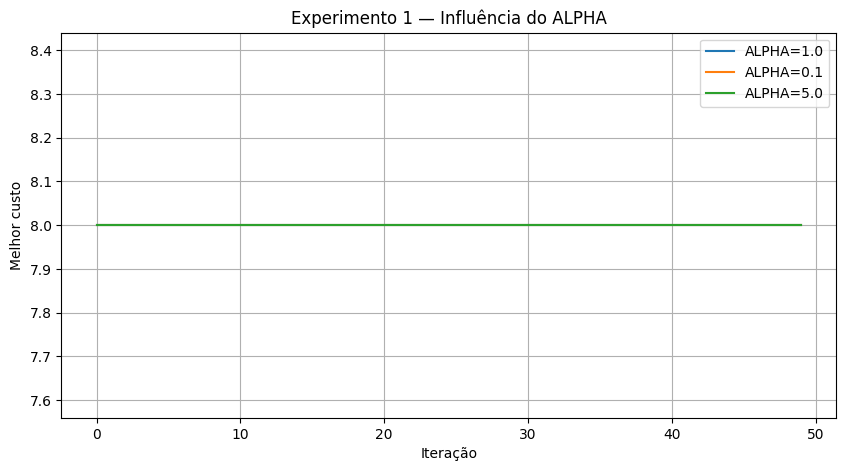

In [4]:
# ============================================================
historicos_alpha = {}
for alpha_teste in [1.0, 0.1, 5.0]:
    hist = mostrar_resultado(f"ALPHA={alpha_teste}", 20, 50, alpha_teste, 2.0, 0.5)
    historicos_alpha[alpha_teste] = hist

plt.figure(figsize=(10, 5))
for alpha_teste, hist in historicos_alpha.items():
    plt.plot(hist, label=f"ALPHA={alpha_teste}")
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Experimento 1 — Influência do ALPHA")
plt.legend()
plt.grid()
plt.show()

In [5]:
# ============================================================
# EXPERIMENTO 2 — Influência do BETA


========== RESULTADO DO EXPERIMENTO: BETA=2.0 ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO: BETA=0.5 ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 0.5
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO: BETA=5.0 ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 5.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


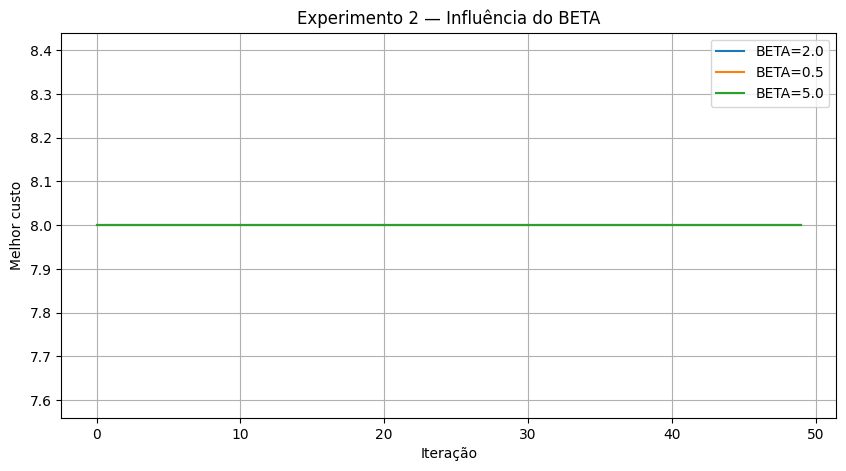

In [6]:
# ============================================================
historicos_beta = {}
for beta_teste in [2.0, 0.5, 5.0]:
    hist = mostrar_resultado(f"BETA={beta_teste}", 20, 50, 1.0, beta_teste, 0.5)
    historicos_beta[beta_teste] = hist

plt.figure(figsize=(10, 5))
for beta_teste, hist in historicos_beta.items():
    plt.plot(hist, label=f"BETA={beta_teste}")
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Experimento 2 — Influência do BETA")
plt.legend()
plt.grid()
plt.show()

In [7]:
# ============================================================
# EXPERIMENTO 3 — Evaporação


========== RESULTADO DO EXPERIMENTO: EVAPORACAO=0.5 ==========


Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO: EVAPORACAO=0.1 ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.1
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO: EVAPORACAO=0.9 ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.9
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


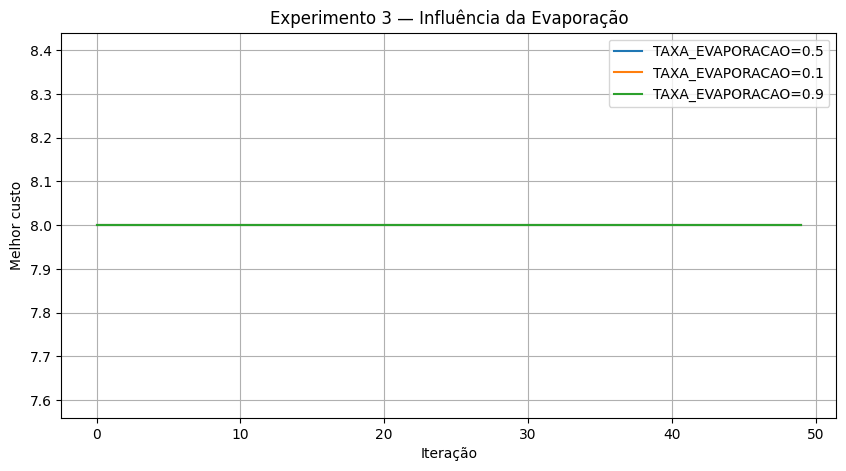

In [8]:
# ============================================================
historicos_evap = {}
for evap_teste in [0.5, 0.1, 0.9]:
    hist = mostrar_resultado(f"EVAPORACAO={evap_teste}", 20, 50, 1.0, 2.0, evap_teste)
    historicos_evap[evap_teste] = hist

plt.figure(figsize=(10, 5))
for evap_teste, hist in historicos_evap.items():
    plt.plot(hist, label=f"TAXA_EVAPORACAO={evap_teste}")
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Experimento 3 — Influência da Evaporação")
plt.legend()
plt.grid()
plt.show()

In [9]:
# ============================================================
# EXPERIMENTO 4 — Número de formigas


========== RESULTADO DO EXPERIMENTO: NUM_FORMIGAS=20 ==========
Número de formigas: 20
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO: NUM_FORMIGAS=5 ==========
Número de formigas: 5
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0

========== RESULTADO DO EXPERIMENTO: NUM_FORMIGAS=50 ==========
Número de formigas: 50
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


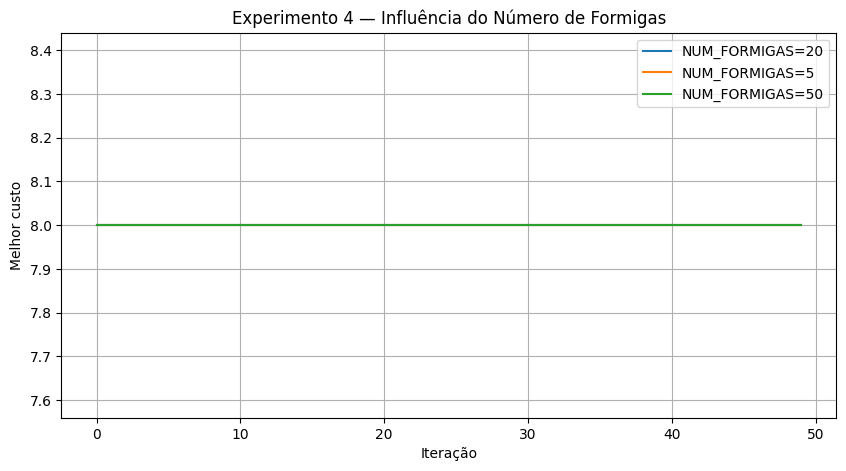

In [10]:
# ============================================================
historicos_formigas = {}
for n_formigas_teste in [20, 5, 50]:
    hist = mostrar_resultado(f"NUM_FORMIGAS={n_formigas_teste}", n_formigas_teste, 50, 1.0, 2.0, 0.5)
    historicos_formigas[n_formigas_teste] = hist

plt.figure(figsize=(10, 5))
for n_formigas_teste, hist in historicos_formigas.items():
    plt.plot(hist, label=f"NUM_FORMIGAS={n_formigas_teste}")
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Experimento 4 — Influência do Número de Formigas")
plt.legend()
plt.grid()
plt.show()